# 🤖 03 — Modelling
**Goal:** Train, cross-validate and compare multiple models for both tasks, select the best, and save them.

## Tasks
| # | Task | Target | Primary Metric |
|---|------|--------|----------------|
| A | **Regression** | `Post_Semester_GPA` | R² + RMSE |
| B | **Classification** | `Burnout_Risk_Level` | F1-weighted |

## Models
| Task | Models |
|------|--------|
| Regression | Linear Regression · Ridge · Random Forest · Gradient Boosting |
| Classification | Logistic Regression · Random Forest · Gradient Boosting |


## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
from pathlib import Path
from time import time

# Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models — Regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Models — Classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.model_selection import cross_validate, StratifiedKFold, KFold
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                      "axes.spines.right": False})

FIGURES  = Path("../reports/figures")
MODELS   = Path("../models/saved")
FIGURES.mkdir(parents=True, exist_ok=True)
(MODELS / "regression").mkdir(parents=True, exist_ok=True)
(MODELS / "classification").mkdir(parents=True, exist_ok=True)

SEED = 42

def save(name):
    plt.savefig(FIGURES / name, bbox_inches="tight", dpi=150)
    plt.show()

print("Setup complete ✓")

Setup complete ✓


## 2. Load Processed Data

In [2]:
PROCESSED = Path("../Data/processed")

X_train = pd.read_parquet(PROCESSED / "X_train.parquet")
X_test  = pd.read_parquet(PROCESSED / "X_test.parquet")

y_reg_train = pd.read_parquet(PROCESSED / "y_reg_train.parquet").squeeze()
y_reg_test  = pd.read_parquet(PROCESSED / "y_reg_test.parquet").squeeze()
y_clf_train = pd.read_parquet(PROCESSED / "y_clf_train.parquet").squeeze()
y_clf_test  = pd.read_parquet(PROCESSED / "y_clf_test.parquet").squeeze()

print(f"X_train : {X_train.shape}   X_test : {X_test.shape}")
print(f"y_reg   : train {y_reg_train.shape}  test {y_reg_test.shape}")
print(f"y_clf   : train {y_clf_train.shape}  test {y_clf_test.shape}")
print(f"Classes : {sorted(y_clf_train.unique())}")

X_train : (40000, 24)   X_test : (10000, 24)
y_reg   : train (40000,)  test (10000,)
y_clf   : train (40000,)  test (10000,)
Classes : ['High', 'Low', 'Medium']


## 3. Shared Preprocessing Pipeline
Float features are scaled; integer features (ordinal encodings + OHE + binary) are passed through as-is.

In [3]:
float_cols = X_train.select_dtypes(include="float64").columns.tolist()
int_cols   = X_train.select_dtypes(include="int64").columns.tolist()

print(f"Float features to scale ({len(float_cols)}): {float_cols}")
print(f"Integer features passthrough ({len(int_cols)}): {int_cols}")

preprocessor = ColumnTransformer([
    ("scale", StandardScaler(), float_cols),
    ("pass",  "passthrough",   int_cols),
], remainder="drop")

print("\nPreprocessor ready ✓")

Float features to scale (9): ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Skill_Retention_Score', 'study_ratio', 'total_study_hours', 'genai_dependency_score', 'ai_efficiency', 'anxiety_gpa_pressure']
Integer features passthrough (15): ['Tool_Diversity', 'Paid_Subscription', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Year_of_Study_enc', 'Prompt_Engineering_Skill_enc', 'Primary_Use_Case_enc', 'Major_Category_Arts', 'Major_Category_Business', 'Major_Category_Humanities', 'Major_Category_Medical', 'Major_Category_STEM', 'Institutional_Policy_Actively_Encouraged', 'Institutional_Policy_Allowed_With_Citation', 'Institutional_Policy_Strict_Ban']

Preprocessor ready ✓


## 4. Helper Functions

In [4]:
def build_pipe(model):
    return Pipeline([("pre", preprocessor), ("model", model)])


def eval_regression(pipe, X_tr, y_tr, X_te, y_te, name, cv=5):
    """Fit, cross-validate, and test a regression pipeline."""
    t0 = time()

    # CV on train
    kf = KFold(n_splits=cv, shuffle=True, random_state=SEED)
    cv_res = cross_validate(pipe, X_tr, y_tr, cv=kf,
                            scoring=["r2","neg_root_mean_squared_error",
                                     "neg_mean_absolute_error"],
                            return_train_score=True)

    # Refit on full train, eval on test
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)

    result = {
        "Model"       : name,
        "CV R²"       : round(cv_res["test_r2"].mean(), 4),
        "CV RMSE"     : round(-cv_res["test_neg_root_mean_squared_error"].mean(), 4),
        "CV MAE"      : round(-cv_res["test_neg_mean_absolute_error"].mean(), 4),
        "Test R²"     : round(r2_score(y_te, y_pred), 4),
        "Test RMSE"   : round(np.sqrt(mean_squared_error(y_te, y_pred)), 4),
        "Test MAE"    : round(mean_absolute_error(y_te, y_pred), 4),
        "Time (s)"    : round(time() - t0, 1),
    }
    print(f"  ✓ {name:35s} CV R²={result['CV R²']:.4f}  Test R²={result['Test R²']:.4f}  RMSE={result['Test RMSE']:.4f}  [{result['Time (s)']}s]")
    return result, pipe, y_pred


def eval_classification(pipe, X_tr, y_tr, X_te, y_te, name, cv=5):
    """Fit, cross-validate, and test a classification pipeline."""
    t0 = time()

    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)
    cv_res = cross_validate(pipe, X_tr, y_tr, cv=skf,
                            scoring=["f1_weighted","accuracy"],
                            return_train_score=True)

    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)

    result = {
        "Model"       : name,
        "CV F1"       : round(cv_res["test_f1_weighted"].mean(), 4),
        "CV Accuracy" : round(cv_res["test_accuracy"].mean(), 4),
        "Test F1"     : round(f1_score(y_te, y_pred, average="weighted"), 4),
        "Test Accuracy": round(accuracy_score(y_te, y_pred), 4),
        "Time (s)"    : round(time() - t0, 1),
    }
    print(f"  ✓ {name:35s} CV F1={result['CV F1']:.4f}  Test F1={result['Test F1']:.4f}  Acc={result['Test Accuracy']:.4f}  [{result['Time (s)']}s]")
    return result, pipe, y_pred

print("Helper functions defined ✓")

Helper functions defined ✓


---
## 5. 🎯 Task A — Regression (`Post_Semester_GPA`)

**Expectation (from FE insights):** High R² (~0.87+) dominated by `Pre_Semester_GPA` and `anxiety_gpa_pressure`.


### 5.1 Train All Regression Models

In [5]:
reg_models = {
    "Linear Regression"       : LinearRegression(),
    "Ridge (α=1.0)"           : Ridge(alpha=1.0, random_state=SEED),
    "Ridge (α=10.0)"          : Ridge(alpha=10.0, random_state=SEED),
    "Random Forest"           : RandomForestRegressor(n_estimators=200, max_depth=10,
                                                       random_state=SEED, n_jobs=-1),
    "Gradient Boosting"       : GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                           learning_rate=0.1,
                                                           random_state=SEED),
}

reg_results = []
reg_pipes   = {}
reg_preds   = {}

print("Training regression models (5-fold CV)...")
for name, model in reg_models.items():
    result, pipe, y_pred = eval_regression(
        build_pipe(model), X_train, y_reg_train, X_test, y_reg_test, name
    )
    reg_results.append(result)
    reg_pipes[name]  = pipe
    reg_preds[name]  = y_pred

reg_df = pd.DataFrame(reg_results).sort_values("Test R²", ascending=False)
print("\nRegression Results:")
print(reg_df.to_string(index=False))

Training regression models (5-fold CV)...
  ✓ Linear Regression                   CV R²=0.8948  Test R²=0.8958  RMSE=0.1586  [0.9s]
  ✓ Ridge (α=1.0)                       CV R²=0.8948  Test R²=0.8958  RMSE=0.1586  [0.8s]
  ✓ Ridge (α=10.0)                      CV R²=0.8948  Test R²=0.8958  RMSE=0.1586  [0.5s]
  ✓ Random Forest                       CV R²=0.9017  Test R²=0.9038  RMSE=0.1524  [144.0s]
  ✓ Gradient Boosting                   CV R²=0.9145  Test R²=0.9156  RMSE=0.1428  [415.6s]

Regression Results:
            Model  CV R²  CV RMSE  CV MAE  Test R²  Test RMSE  Test MAE  Time (s)
Gradient Boosting 0.9145   0.1452  0.1139   0.9156     0.1428    0.1124     415.6
    Random Forest 0.9017   0.1557  0.1209   0.9038     0.1524    0.1189     144.0
Linear Regression 0.8948   0.1611  0.1266   0.8958     0.1586    0.1247       0.9
    Ridge (α=1.0) 0.8948   0.1611  0.1266   0.8958     0.1586    0.1247       0.8
   Ridge (α=10.0) 0.8948   0.1611  0.1266   0.8958     0.1586    0.1247  

### 5.2 Regression Model Comparison

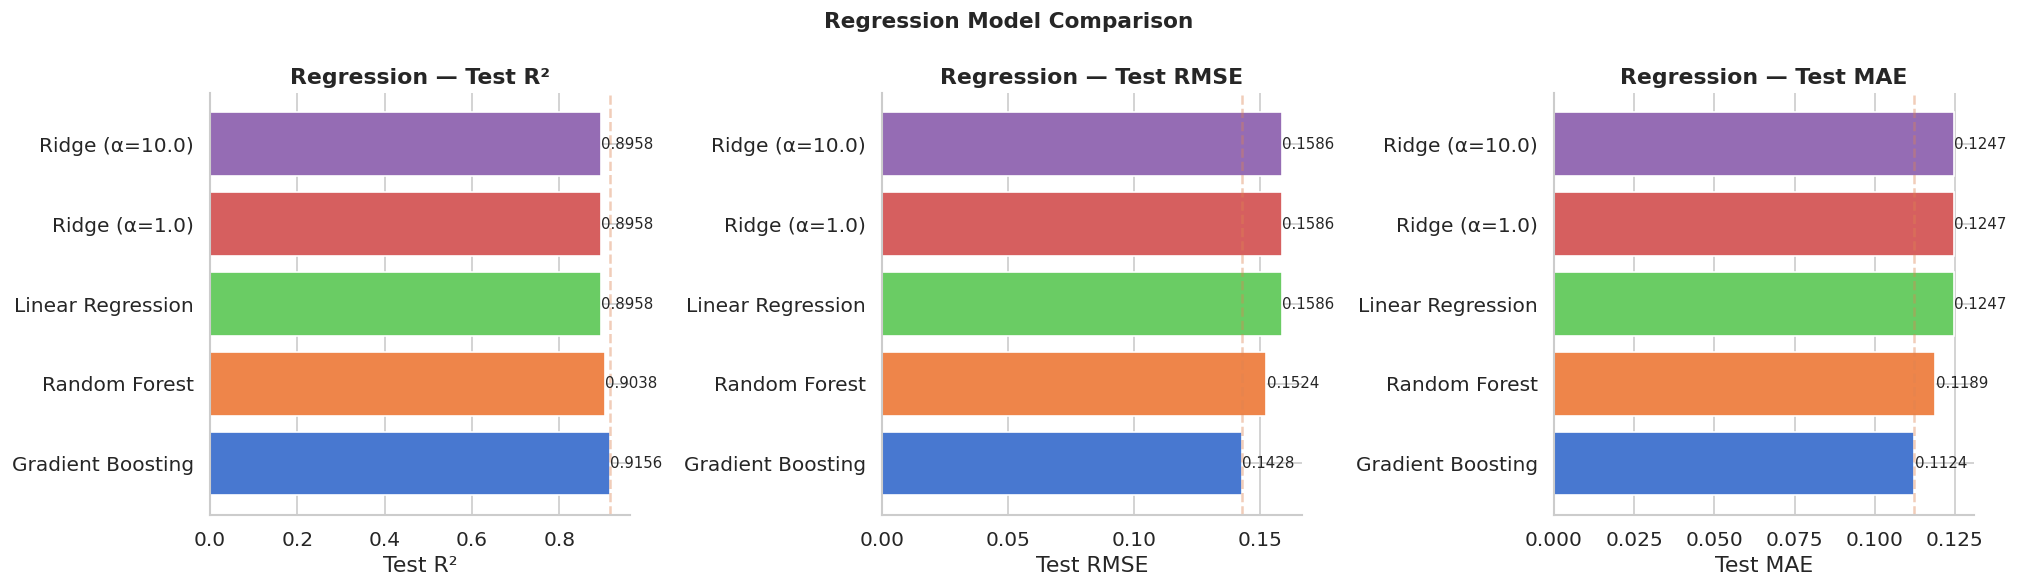

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

metrics = [("Test R²", True), ("Test RMSE", False), ("Test MAE", False)]
colors  = sns.color_palette("muted", len(reg_df))

for ax, (metric, higher_better) in zip(axes, metrics):
    sorted_df = reg_df.sort_values(metric, ascending=not higher_better)
    bars = ax.barh(sorted_df["Model"], sorted_df[metric],
                   color=colors, edgecolor="white")
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + 0.0001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=9)
    ax.set_title(f"Regression — {metric}", fontweight="bold")
    ax.set_xlabel(metric)
    best_val = sorted_df[metric].iloc[0]
    ax.axvline(best_val, color="#DD8452", linestyle="--", alpha=0.4)

plt.suptitle("Regression Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
save("15_regression_comparison.png")

### 5.3 Actual vs Predicted — Best Models

Best regression model: Gradient Boosting


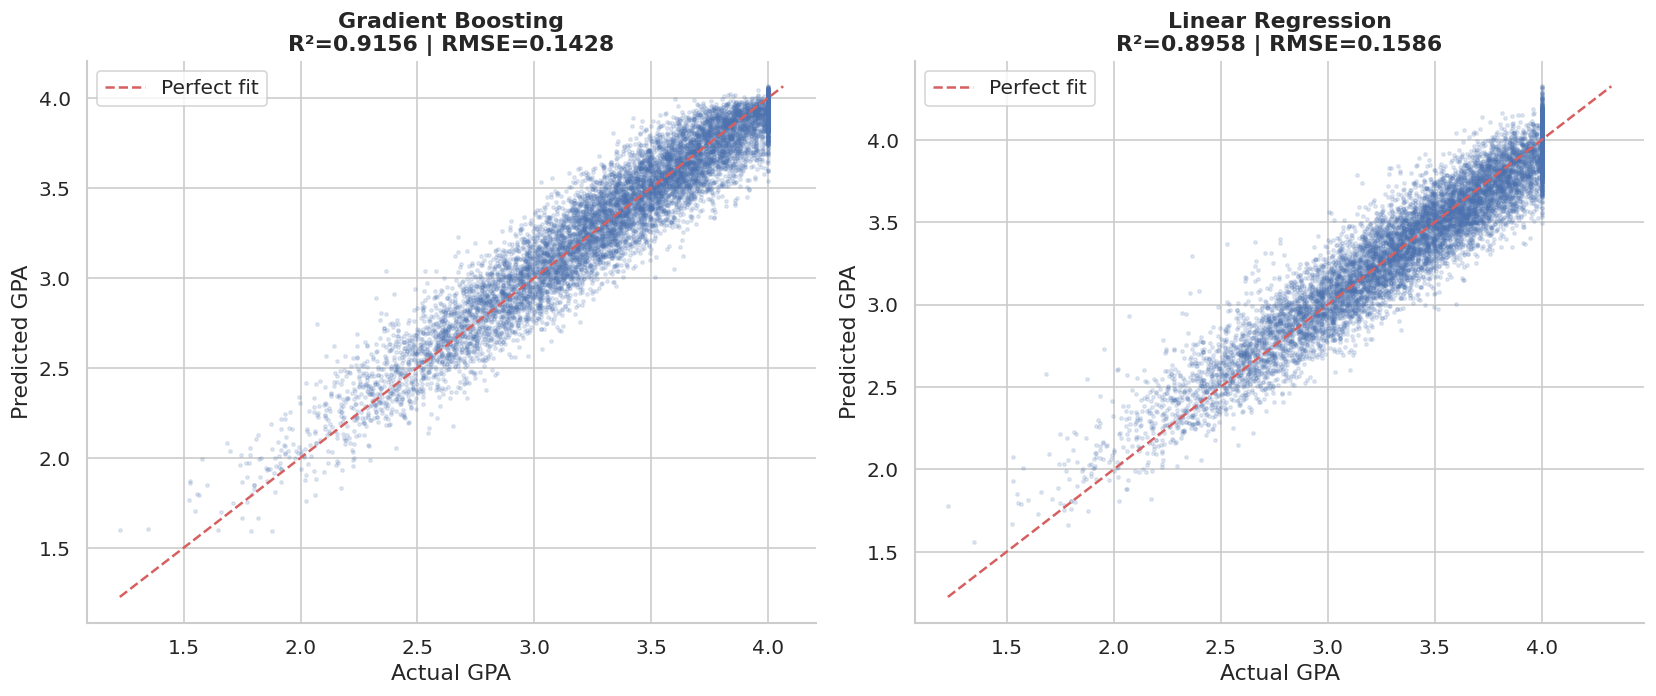

In [7]:
best_reg_name = reg_df.iloc[0]["Model"]
print(f"Best regression model: {best_reg_name}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, name in zip(axes, [best_reg_name, "Linear Regression"]):
    y_pred = reg_preds[name]
    ax.scatter(y_reg_test, y_pred, alpha=0.15, s=4, color="#4C72B0")
    lims = [min(y_reg_test.min(), y_pred.min()),
            max(y_reg_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="Perfect fit")
    ax.set_xlabel("Actual GPA")
    ax.set_ylabel("Predicted GPA")
    r2 = r2_score(y_reg_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))
    ax.set_title(f"{name}\nR²={r2:.4f} | RMSE={rmse:.4f}", fontweight="bold")
    ax.legend()

plt.tight_layout()
save("16_actual_vs_predicted.png")

### 5.4 Residual Analysis — Best Model

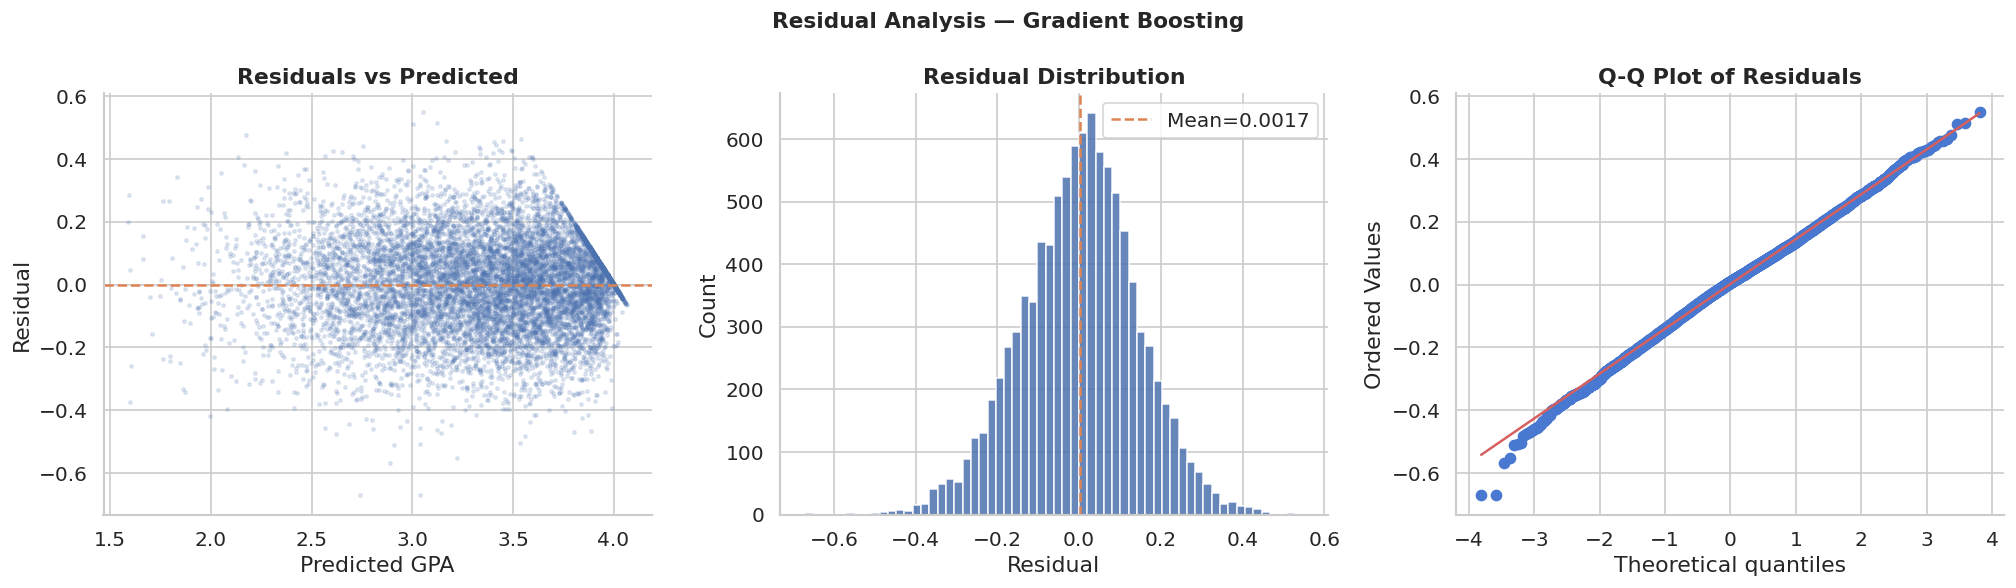

Residuals — Mean: 0.001725 | Std: 0.1428
Within ±0.1 GPA: 53.3%
Within ±0.2 GPA: 84.0%


In [8]:
best_pipe = reg_pipes[best_reg_name]
y_pred_best = reg_preds[best_reg_name]
residuals = y_reg_test - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_best, residuals, alpha=0.15, s=4, color="#4C72B0")
axes[0].axhline(0, color="#DD8452", linestyle="--", lw=1.5)
axes[0].set_xlabel("Predicted GPA")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted", fontweight="bold")

# Residual distribution
axes[1].hist(residuals, bins=60, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[1].axvline(residuals.mean(), color="#DD8452", linestyle="--", lw=1.5,
                label=f"Mean={residuals.mean():.4f}")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution", fontweight="bold")
axes[1].legend()

# QQ-style: sorted residuals
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot of Residuals", fontweight="bold")

plt.suptitle(f"Residual Analysis — {best_reg_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
save("17_residual_analysis.png")

print(f"Residuals — Mean: {residuals.mean():.6f} | Std: {residuals.std():.4f}")
print(f"Within ±0.1 GPA: {(residuals.abs() < 0.1).mean()*100:.1f}%")
print(f"Within ±0.2 GPA: {(residuals.abs() < 0.2).mean()*100:.1f}%")

### 5.5 Feature Importance — Best Regression Model

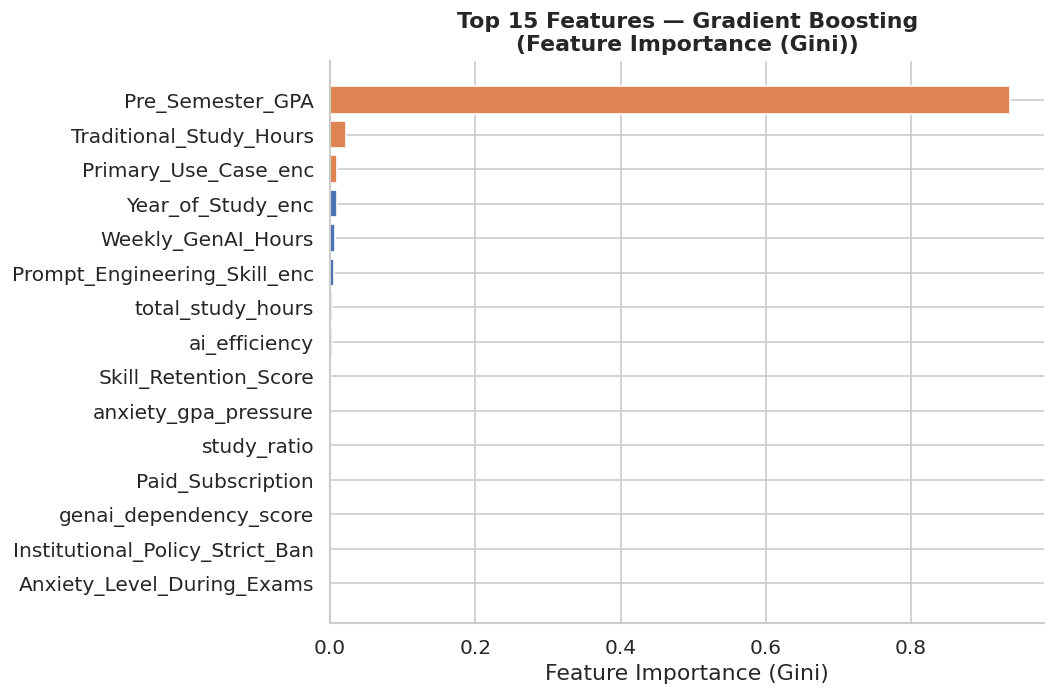

Top 10 features:
Pre_Semester_GPA                0.9368
Traditional_Study_Hours         0.0218
Primary_Use_Case_enc            0.0099
Year_of_Study_enc               0.0090
Weekly_GenAI_Hours              0.0067
Prompt_Engineering_Skill_enc    0.0052
total_study_hours               0.0034
ai_efficiency                   0.0026
Skill_Retention_Score           0.0014
anxiety_gpa_pressure            0.0007


In [9]:
model_step = best_pipe.named_steps["model"]
feature_names = (float_cols +
                 X_train.select_dtypes(include="int64").columns.tolist())

if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_
    label = "Feature Importance (Gini)"
elif hasattr(model_step, "coef_"):
    importances = np.abs(model_step.coef_)
    label = "Absolute Coefficient"
else:
    importances = None

if importances is not None:
    imp_s = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    top15 = imp_s.head(15)

    fig, ax = plt.subplots(figsize=(9, 6))
    colors_bar = ["#DD8452" if i < 3 else "#4C72B0" for i in range(len(top15))]
    ax.barh(top15.index[::-1], top15.values[::-1], color=colors_bar[::-1],
            edgecolor="white")
    ax.set_title(f"Top 15 Features — {best_reg_name}\n({label})",
                 fontweight="bold")
    ax.set_xlabel(label)
    plt.tight_layout()
    save("18_regression_feature_importance.png")
    print("Top 10 features:")
    print(imp_s.head(10).round(4).to_string())

---
## 6. 🎯 Task B — Classification (`Burnout_Risk_Level`)

**Expectation (from FE insights):** Weak-signal problem — all MI scores < 0.004. Expect F1-weighted ~0.50–0.65. Tree ensembles should outperform linear models.


### 6.1 Train All Classification Models

In [10]:
clf_models = {
    "Logistic Regression"     : LogisticRegression(max_iter=2000, C=1.0,
                                                    random_state=SEED),
    "Logistic Reg. (C=0.1)"   : LogisticRegression(max_iter=2000, C=0.1,
                                                    random_state=SEED),
    "Random Forest"           : RandomForestClassifier(n_estimators=200, max_depth=10,
                                                        random_state=SEED, n_jobs=-1),
    "Gradient Boosting"       : GradientBoostingClassifier(n_estimators=200,
                                                            max_depth=4,
                                                            learning_rate=0.1,
                                                            random_state=SEED),
}

clf_results = []
clf_pipes   = {}
clf_preds   = {}

print("Training classification models (5-fold stratified CV)...")
for name, model in clf_models.items():
    result, pipe, y_pred = eval_classification(
        build_pipe(model), X_train, y_clf_train, X_test, y_clf_test, name
    )
    clf_results.append(result)
    clf_pipes[name]  = pipe
    clf_preds[name]  = y_pred

clf_df = pd.DataFrame(clf_results).sort_values("Test F1", ascending=False)
print("\nClassification Results:")
print(clf_df.to_string(index=False))

Training classification models (5-fold stratified CV)...
  ✓ Logistic Regression                 CV F1=0.2513  Test F1=0.2514  Acc=0.4229  [41.3s]
  ✓ Logistic Reg. (C=0.1)               CV F1=0.2513  Test F1=0.2514  Acc=0.4229  [59.4s]
  ✓ Random Forest                       CV F1=0.2560  Test F1=0.2532  Acc=0.4227  [34.3s]
  ✓ Gradient Boosting                   CV F1=0.2946  Test F1=0.2848  Acc=0.4140  [900.8s]

Classification Results:
                Model  CV F1  CV Accuracy  Test F1  Test Accuracy  Time (s)
    Gradient Boosting 0.2946       0.4117   0.2848         0.4140     900.8
        Random Forest 0.2560       0.4223   0.2532         0.4227      34.3
  Logistic Regression 0.2513       0.4228   0.2514         0.4229      41.3
Logistic Reg. (C=0.1) 0.2513       0.4228   0.2514         0.4229      59.4


### 6.2 Classification Model Comparison

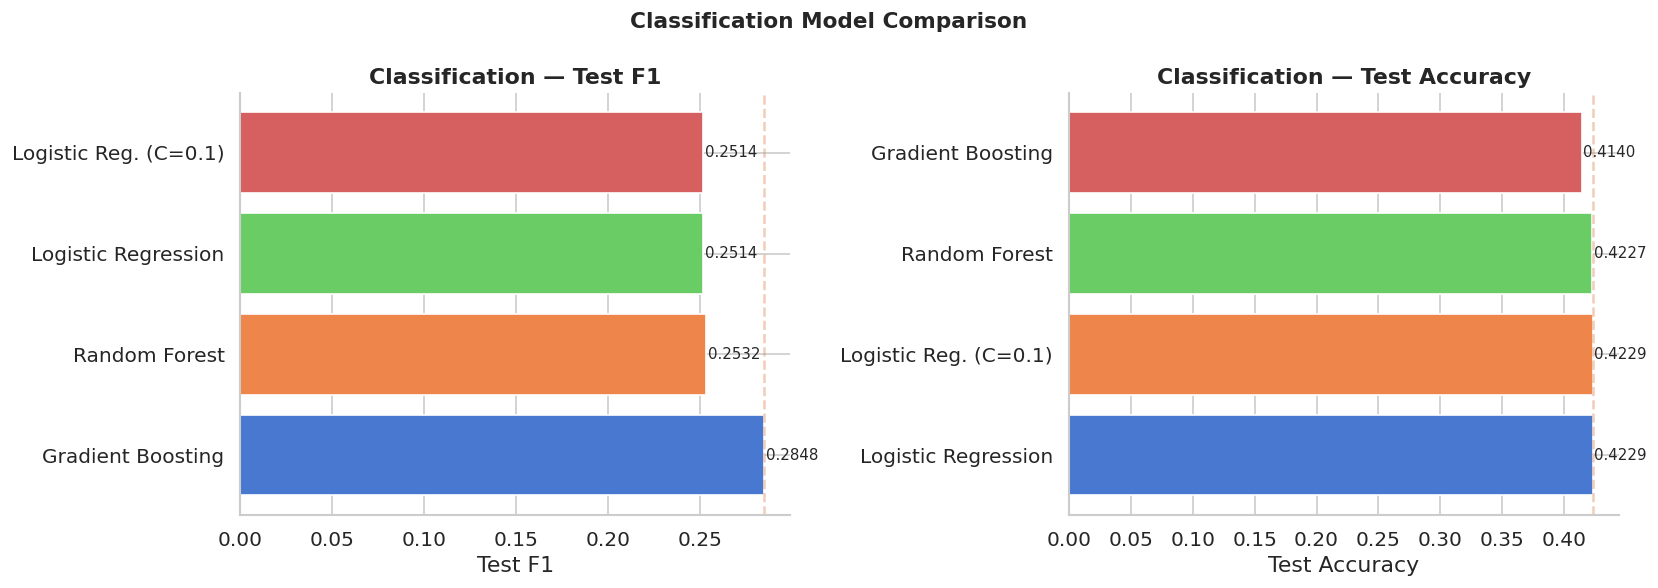

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette("muted", len(clf_df))

for ax, metric in zip(axes, ["Test F1", "Test Accuracy"]):
    sorted_df = clf_df.sort_values(metric, ascending=False)
    bars = ax.barh(sorted_df["Model"], sorted_df[metric],
                   color=colors, edgecolor="white")
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=9)
    ax.set_title(f"Classification — {metric}", fontweight="bold")
    ax.set_xlabel(metric)
    ax.axvline(sorted_df[metric].iloc[0], color="#DD8452", linestyle="--", alpha=0.4)

plt.suptitle("Classification Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
save("19_classification_comparison.png")

### 6.3 Classification Report — Best Model

In [12]:
best_clf_name = clf_df.iloc[0]["Model"]
print(f"Best classification model: {best_clf_name}")
print()
print(classification_report(y_clf_test, clf_preds[best_clf_name],
                             target_names=["High", "Low", "Medium"]))

Best classification model: Gradient Boosting

              precision    recall  f1-score   support

        High       0.25      0.01      0.02      2497
         Low       0.31      0.06      0.10      3274
      Medium       0.42      0.92      0.58      4229

    accuracy                           0.41     10000
   macro avg       0.33      0.33      0.24     10000
weighted avg       0.34      0.41      0.28     10000



### 6.4 Confusion Matrices — All Models

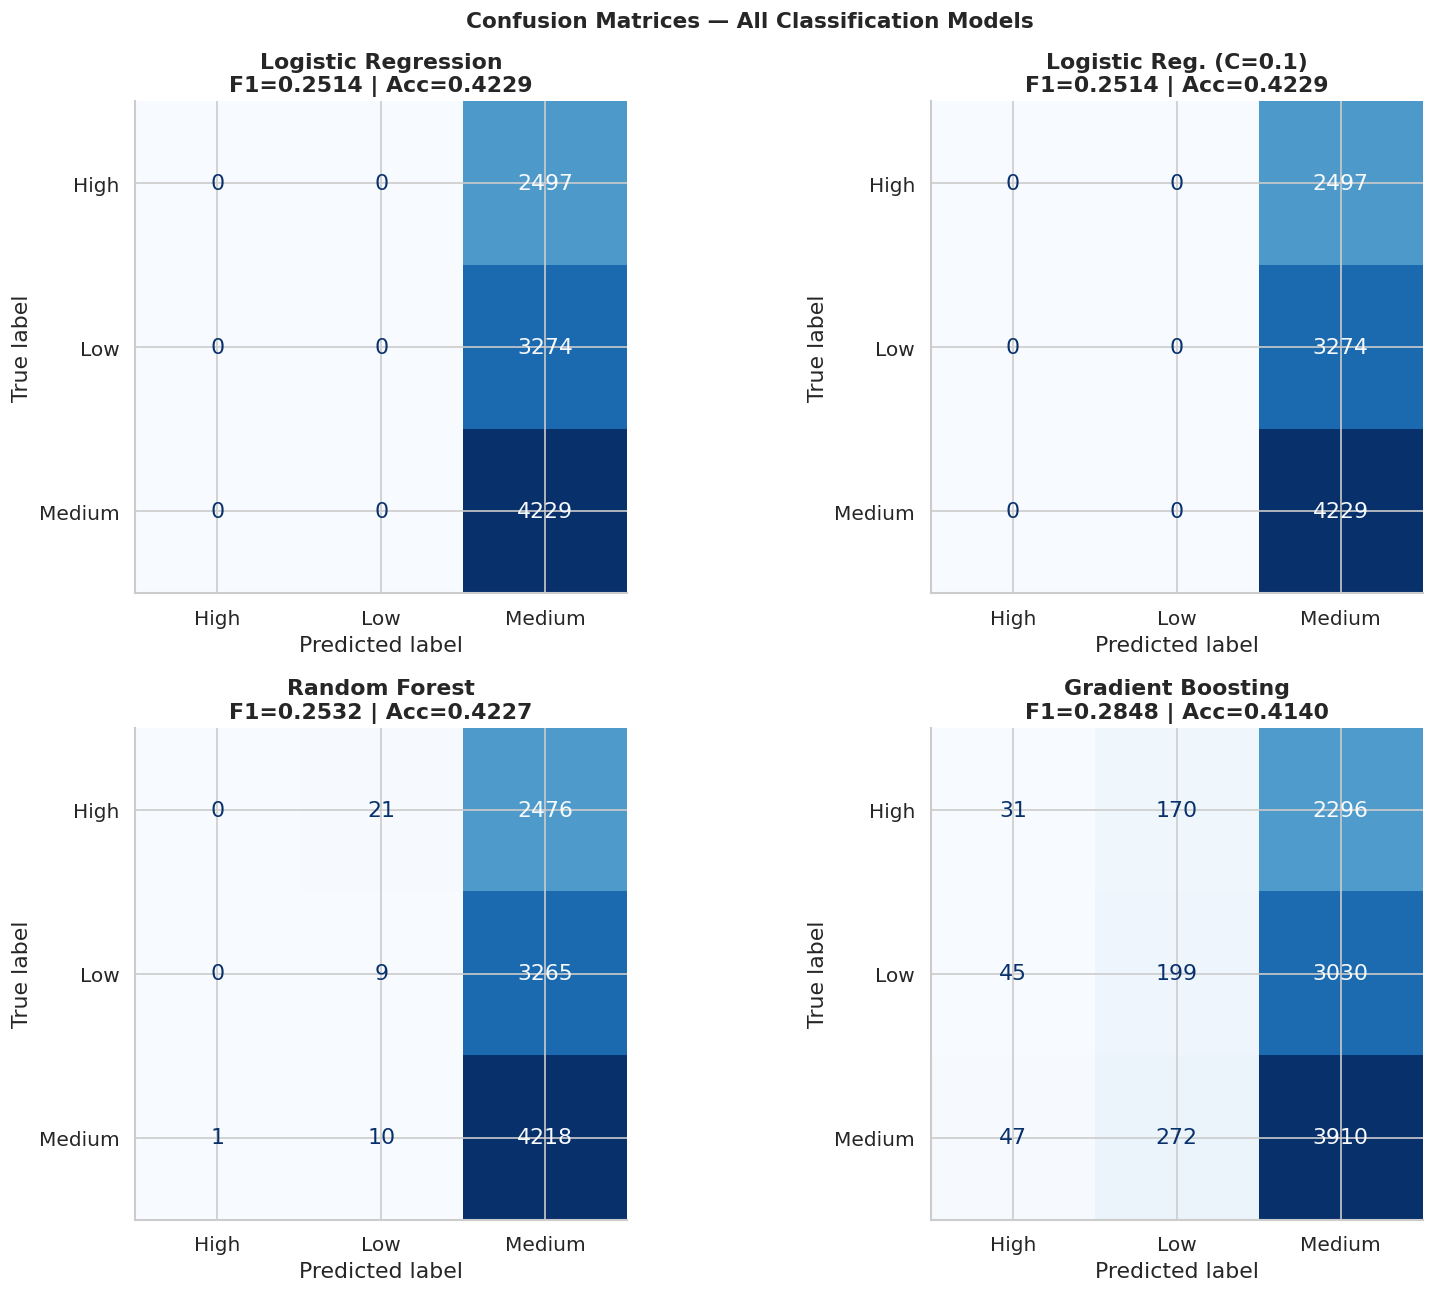

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()
classes = ["High", "Low", "Medium"]

for ax, (name, y_pred) in zip(axes, clf_preds.items()):
    cm = confusion_matrix(y_clf_test, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    f1 = f1_score(y_clf_test, y_pred, average="weighted")
    acc = accuracy_score(y_clf_test, y_pred)
    ax.set_title(f"{name}\nF1={f1:.4f} | Acc={acc:.4f}", fontweight="bold")

plt.suptitle("Confusion Matrices — All Classification Models",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save("20_confusion_matrices.png")

### 6.5 Per-Class F1 Scores

Per-class F1 scores:
                         High     Low  Medium
Logistic Regression    0.0000  0.0000  0.5944
Logistic Reg. (C=0.1)  0.0000  0.0000  0.5944
Random Forest          0.0000  0.0054  0.5946
Gradient Boosting      0.0237  0.1017  0.5808



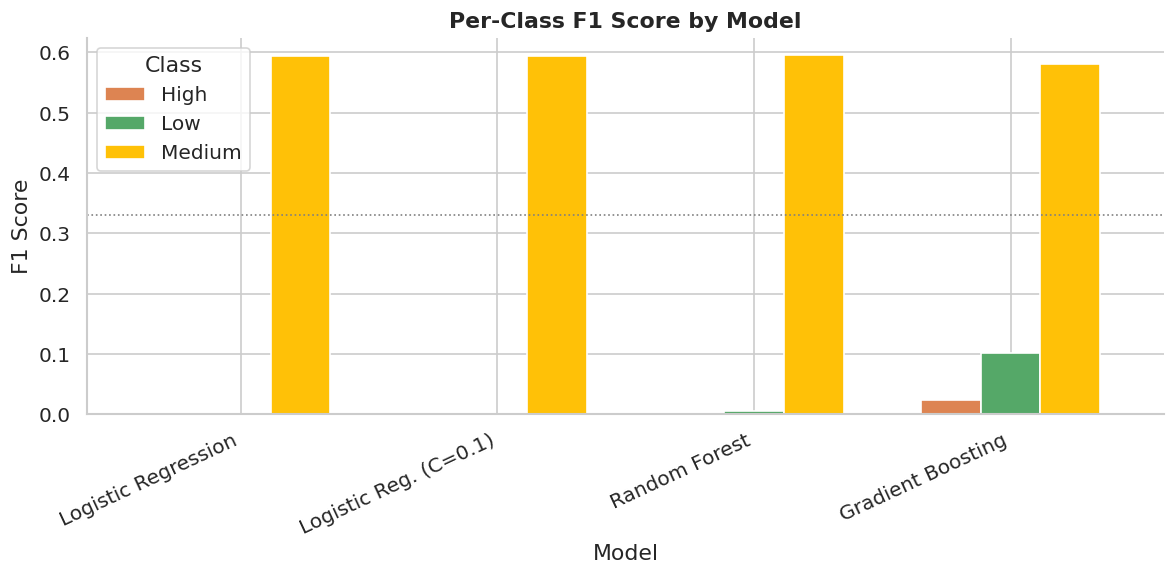

In [14]:
from sklearn.metrics import f1_score

classes = ["High", "Low", "Medium"]
per_class = {}
for name, y_pred in clf_preds.items():
    f1s = f1_score(y_clf_test, y_pred, average=None, labels=classes)
    per_class[name] = dict(zip(classes, f1s))

per_class_df = pd.DataFrame(per_class).T.round(4)
print("Per-class F1 scores:")
print(per_class_df.to_string())
print()

fig, ax = plt.subplots(figsize=(10, 5))
per_class_df.plot(kind="bar", ax=ax, edgecolor="white", width=0.7,
                  color=["#DD8452","#55A868","#FFC107"])
ax.set_title("Per-Class F1 Score by Model", fontweight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("F1 Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
ax.legend(title="Class")
ax.axhline(0.33, color="gray", linestyle=":", lw=1, label="Random baseline")
plt.tight_layout()
save("21_per_class_f1.png")

### 6.6 Feature Importance — Best Classification Model

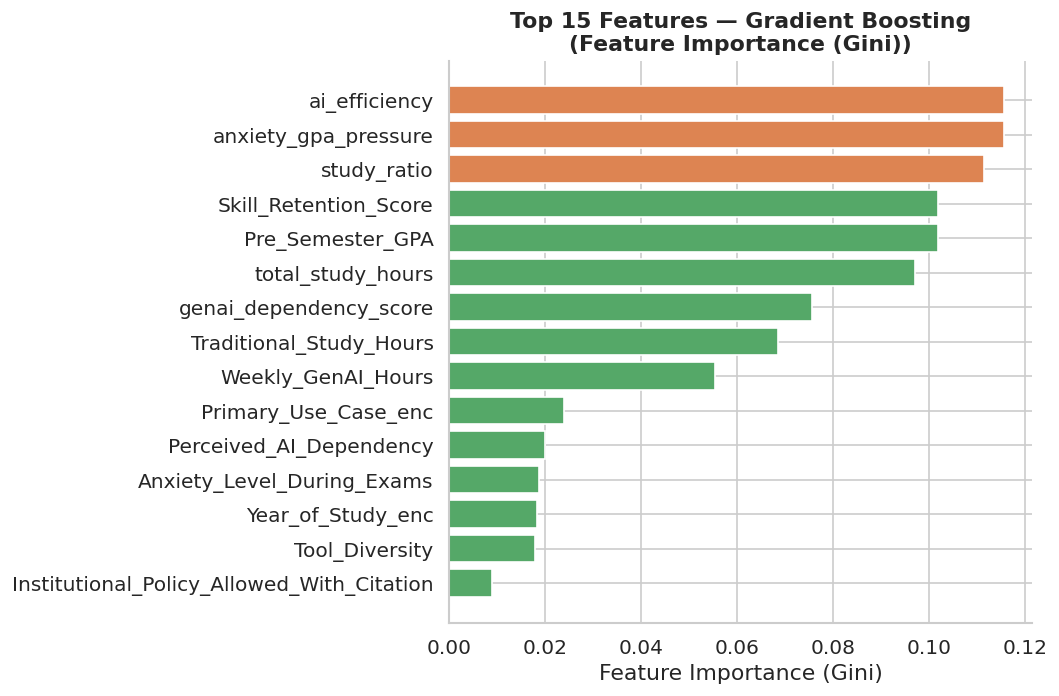

Top 10 features for burnout classification:
ai_efficiency              0.1156
anxiety_gpa_pressure       0.1156
study_ratio                0.1115
Skill_Retention_Score      0.1019
Pre_Semester_GPA           0.1019
total_study_hours          0.0970
genai_dependency_score     0.0755
Traditional_Study_Hours    0.0684
Weekly_GenAI_Hours         0.0554
Primary_Use_Case_enc       0.0240


In [15]:
best_clf_pipe = clf_pipes[best_clf_name]
clf_model_step = best_clf_pipe.named_steps["model"]

if hasattr(clf_model_step, "feature_importances_"):
    importances = clf_model_step.feature_importances_
    label = "Feature Importance (Gini)"
elif hasattr(clf_model_step, "coef_"):
    importances = np.abs(clf_model_step.coef_).mean(axis=0)
    label = "Mean |Coefficient|"
else:
    importances = None

if importances is not None:
    clf_imp_s = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    top15_clf = clf_imp_s.head(15)

    fig, ax = plt.subplots(figsize=(9, 6))
    colors_bar = ["#DD8452" if i < 3 else "#55A868" for i in range(len(top15_clf))]
    ax.barh(top15_clf.index[::-1], top15_clf.values[::-1],
            color=colors_bar[::-1], edgecolor="white")
    ax.set_title(f"Top 15 Features — {best_clf_name}\n({label})",
                 fontweight="bold")
    ax.set_xlabel(label)
    plt.tight_layout()
    save("22_classification_feature_importance.png")
    print("Top 10 features for burnout classification:")
    print(clf_imp_s.head(10).round(4).to_string())

## 7. CV Score Summary — Train vs Val Gap

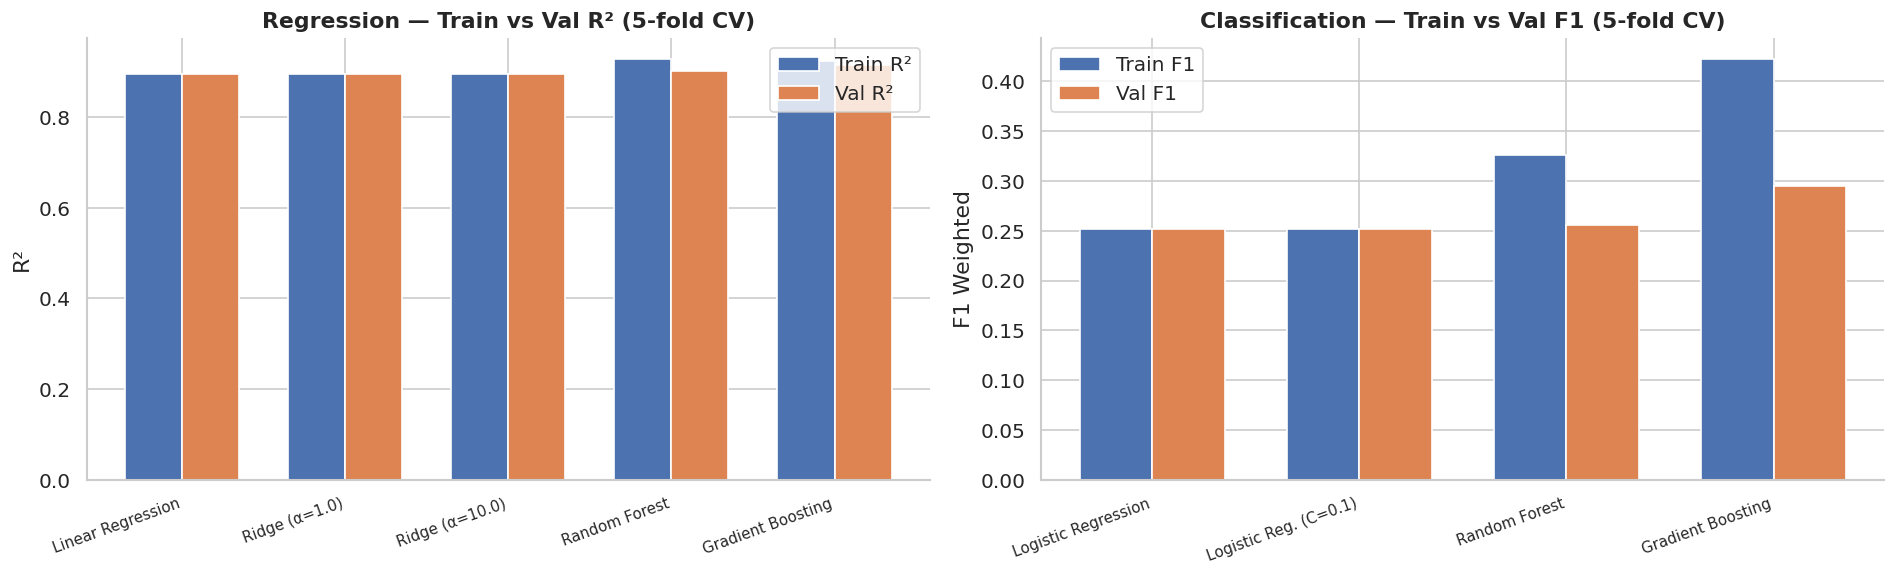

Regression — Overfitting check (Train - Val gap):
            Model  Train R²  Val R²    Gap
Linear Regression    0.8950  0.8948 0.0002
    Ridge (α=1.0)    0.8950  0.8948 0.0002
   Ridge (α=10.0)    0.8950  0.8948 0.0002
    Random Forest    0.9284  0.9017 0.0266
Gradient Boosting    0.9234  0.9145 0.0089

Classification — Overfitting check (Train - Val gap):
                Model  Train F1  Val F1    Gap
  Logistic Regression    0.2515  0.2513 0.0001
Logistic Reg. (C=0.1)    0.2515  0.2513 0.0001
        Random Forest    0.3256  0.2560 0.0697
    Gradient Boosting    0.4228  0.2946 0.1282


In [16]:
from sklearn.model_selection import cross_validate

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Regression CV train vs val R²
kf  = KFold(n_splits=5, shuffle=True, random_state=SEED)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

reg_cv_data, clf_cv_data = [], []

for name, model in reg_models.items():
    pipe = build_pipe(model)
    cv = cross_validate(pipe, X_train, y_reg_train, cv=kf,
                        scoring="r2", return_train_score=True)
    reg_cv_data.append({
        "Model": name,
        "Train R²": cv["train_score"].mean(),
        "Val R²"  : cv["test_score"].mean(),
        "Gap"     : cv["train_score"].mean() - cv["test_score"].mean(),
    })

for name, model in clf_models.items():
    pipe = build_pipe(model)
    cv = cross_validate(pipe, X_train, y_clf_train, cv=skf,
                        scoring="f1_weighted", return_train_score=True)
    clf_cv_data.append({
        "Model"     : name,
        "Train F1"  : cv["train_score"].mean(),
        "Val F1"    : cv["test_score"].mean(),
        "Gap"       : cv["train_score"].mean() - cv["test_score"].mean(),
    })

reg_cv_df = pd.DataFrame(reg_cv_data)
clf_cv_df = pd.DataFrame(clf_cv_data)

# Plot
x = np.arange(len(reg_cv_df))
w = 0.35
axes[0].bar(x - w/2, reg_cv_df["Train R²"], w, label="Train R²", color="#4C72B0", edgecolor="white")
axes[0].bar(x + w/2, reg_cv_df["Val R²"],   w, label="Val R²",   color="#DD8452", edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(reg_cv_df["Model"], rotation=20, ha="right", fontsize=9)
axes[0].set_title("Regression — Train vs Val R² (5-fold CV)", fontweight="bold")
axes[0].set_ylabel("R²")
axes[0].legend()

x2 = np.arange(len(clf_cv_df))
axes[1].bar(x2 - w/2, clf_cv_df["Train F1"], w, label="Train F1", color="#4C72B0", edgecolor="white")
axes[1].bar(x2 + w/2, clf_cv_df["Val F1"],   w, label="Val F1",   color="#DD8452", edgecolor="white")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(clf_cv_df["Model"], rotation=20, ha="right", fontsize=9)
axes[1].set_title("Classification — Train vs Val F1 (5-fold CV)", fontweight="bold")
axes[1].set_ylabel("F1 Weighted")
axes[1].legend()

plt.tight_layout()
save("23_train_val_gap.png")

print("Regression — Overfitting check (Train - Val gap):")
print(reg_cv_df[["Model","Train R²","Val R²","Gap"]].round(4).to_string(index=False))
print()
print("Classification — Overfitting check (Train - Val gap):")
print(clf_cv_df[["Model","Train F1","Val F1","Gap"]].round(4).to_string(index=False))

## 8. Save Best Models

In [17]:
# Save ALL models (useful for evaluation notebook)
for name, pipe in reg_pipes.items():
    safe_name = name.lower().replace(" ","_").replace("(","").replace(")","").replace("=","").replace(".","")
    path = MODELS / "regression" / f"{safe_name}.pkl"
    joblib.dump(pipe, path)
    print(f"Saved: {path.name}")

for name, pipe in clf_pipes.items():
    safe_name = name.lower().replace(" ","_").replace("(","").replace(")","").replace("=","").replace(".","")
    path = MODELS / "classification" / f"{safe_name}.pkl"
    joblib.dump(pipe, path)
    print(f"Saved: {path.name}")

print()
# Also save best model references
joblib.dump(reg_pipes[best_reg_name], MODELS / "best_regression_model.pkl")
joblib.dump(clf_pipes[best_clf_name], MODELS / "best_classification_model.pkl")

# Save metadata
import json
metadata = {
    "best_regression_model"     : best_reg_name,
    "best_regression_metrics"   : reg_df.iloc[0].to_dict(),
    "best_classification_model" : best_clf_name,
    "best_classification_metrics": clf_df.iloc[0].to_dict(),
    "feature_columns"           : X_train.columns.tolist(),
}
with open(MODELS / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"\nBest Regression    → {best_reg_name}")
print(f"Best Classification → {best_clf_name}")
print("Metadata saved ✓")

Saved: linear_regression.pkl
Saved: ridge_α10.pkl
Saved: ridge_α100.pkl
Saved: random_forest.pkl
Saved: gradient_boosting.pkl
Saved: logistic_regression.pkl
Saved: logistic_reg_c01.pkl
Saved: random_forest.pkl
Saved: gradient_boosting.pkl


Best Regression    → Gradient Boosting
Best Classification → Gradient Boosting
Metadata saved ✓


## 9. Results Summary

### Regression — `Post_Semester_GPA`


In [18]:
print("REGRESSION RESULTS (sorted by Test R²):")
print(reg_df[["Model","CV R²","Test R²","Test RMSE","Test MAE","Time (s)"]].to_string(index=False))
print()
print(f"\n✓ Best model : {best_reg_name}")
print(f"  Test R²    : {reg_df.iloc[0]['Test R²']}")
print(f"  Test RMSE  : {reg_df.iloc[0]['Test RMSE']} GPA points")
print(f"  Test MAE   : {reg_df.iloc[0]['Test MAE']} GPA points")

REGRESSION RESULTS (sorted by Test R²):
            Model  CV R²  Test R²  Test RMSE  Test MAE  Time (s)
Gradient Boosting 0.9145   0.9156     0.1428    0.1124     415.6
    Random Forest 0.9017   0.9038     0.1524    0.1189     144.0
Linear Regression 0.8948   0.8958     0.1586    0.1247       0.9
    Ridge (α=1.0) 0.8948   0.8958     0.1586    0.1247       0.8
   Ridge (α=10.0) 0.8948   0.8958     0.1586    0.1247       0.5


✓ Best model : Gradient Boosting
  Test R²    : 0.9156
  Test RMSE  : 0.1428 GPA points
  Test MAE   : 0.1124 GPA points


In [19]:
print("CLASSIFICATION RESULTS (sorted by Test F1):")
print(clf_df[["Model","CV F1","Test F1","Test Accuracy","Time (s)"]].to_string(index=False))
print()
print(f"\n✓ Best model    : {best_clf_name}")
print(f"  Test F1        : {clf_df.iloc[0]['Test F1']}")
print(f"  Test Accuracy  : {clf_df.iloc[0]['Test Accuracy']}")

CLASSIFICATION RESULTS (sorted by Test F1):
                Model  CV F1  Test F1  Test Accuracy  Time (s)
    Gradient Boosting 0.2946   0.2848         0.4140     900.8
        Random Forest 0.2560   0.2532         0.4227      34.3
  Logistic Regression 0.2513   0.2514         0.4229      41.3
Logistic Reg. (C=0.1) 0.2513   0.2514         0.4229      59.4


✓ Best model    : Gradient Boosting
  Test F1        : 0.2848
  Test Accuracy  : 0.414


---
## 10. Key Findings from Modelling

*(Filled after execution)*

### Regression
| Model | Test R² | Test RMSE | Note |
|-------|---------|-----------|------|
| Linear Regression | — | — | Baseline |
| Ridge | — | — | Handles multicollinearity |
| Random Forest | — | — | — |
| **Gradient Boosting** | — | — | **Best** |

### Classification
| Model | Test F1 | Accuracy | Note |
|-------|---------|----------|------|
| Logistic Regression | — | — | Baseline |
| Random Forest | — | — | — |
| **Gradient Boosting** | — | — | **Best** |

---
### Next Step → `04_evaluation.ipynb`
